In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

path = "../data/silver/"

In [17]:
orders = pd.read_parquet(f'{path}olist_orders_dataset.parquet')
items = pd.read_parquet(f'{path}olist_order_items_dataset.parquet')
payments = pd.read_parquet(f'{path}olist_order_payments_dataset.parquet')
customers = pd.read_parquet(f'{path}olist_customers_dataset.parquet')

#### Qual o valor gasto por pedido e como ele varia?

Ticket médio por pedido: R$ 137.75
Desvio padrão: R$ 210.65


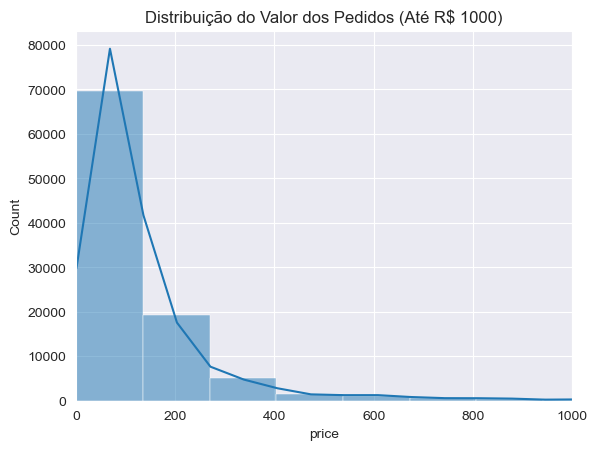

In [18]:
venda_por_pedido = items.groupby("order_id")["price"].sum().reset_index()

mean_ticket = venda_por_pedido["price"].mean()
std_ticket = venda_por_pedido["price"].std()

print(f"Ticket médio por pedido: R$ {mean_ticket:.2f}")
print(f"Desvio padrão: R$ {std_ticket:.2f}")

sns.histplot(venda_por_pedido["price"], bins=100, kde=True)
plt.xlim(0, 1000) 
plt.title("Distribuição do Valor dos Pedidos (Até R$ 1000)")
plt.show()

#### Quais os 5 estados que geram mais receita?

Top 5 Estados por Receita:
customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
Name: price, dtype: float64


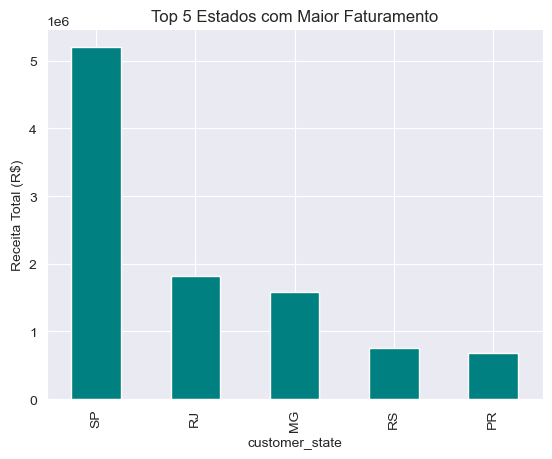

In [19]:
df_receita = items.merge(orders, on='order_id').merge(customers, on='customer_id')

receita_estado = df_receita.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(5)

print("Top 5 Estados por Receita:")
print(receita_estado)

receita_estado.plot(kind='bar', color='teal')
plt.ylabel("Receita Total (R$)")
plt.title("Top 5 Estados com Maior Faturamento")
plt.show()

#### Frete vs cancelamento

is_canceled
False    19.991964
True     19.650277
Name: freight_value, dtype: float64


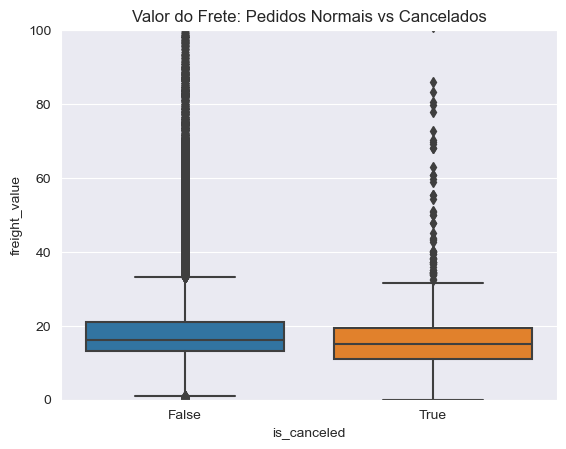

In [20]:
# Criamos uma coluna booleana para cancelados
orders['is_canceled'] = orders['order_status'] == 'canceled'

# Join com itens para pegar o valor do frete
df_frete = orders.merge(items[['order_id', 'freight_value']], on='order_id')

# Comparação de médias
print(df_frete.groupby('is_canceled')['freight_value'].mean())

sns.boxplot(data=df_frete, x='is_canceled', y='freight_value')
plt.ylim(0, 100) # Focando na maioria dos dados
plt.title("Valor do Frete: Pedidos Normais vs Cancelados")
plt.show()

#### Cartão de Crédito vs Outros

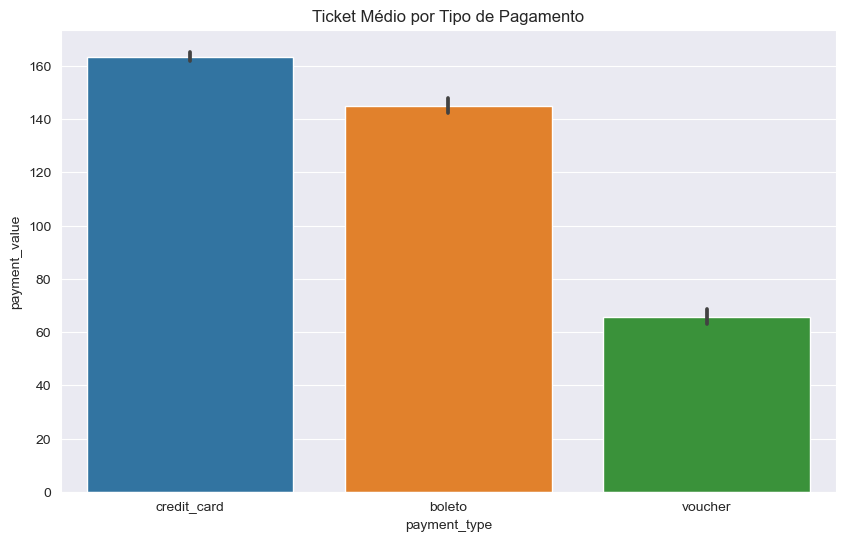

Diferença CC vs Boleto: R$ 18.28


In [21]:
# Filtrando apenas os principais tipos
top_payments = payments[payments['payment_type'].isin(['credit_card', 'boleto', 'voucher'])]

plt.figure(figsize=(10,6))
sns.barplot(data=top_payments, x='payment_type', y='payment_value', estimator=np.mean)
plt.title("Ticket Médio por Tipo de Pagamento")
plt.show()

media_cc = top_payments[top_payments['payment_type'] == 'credit_card']['payment_value'].mean()
media_boleto = top_payments[top_payments['payment_type'] == 'boleto']['payment_value'].mean()
print(f"Diferença CC vs Boleto: R$ {media_cc - media_boleto:.2f}")

#### Capitais vs interior

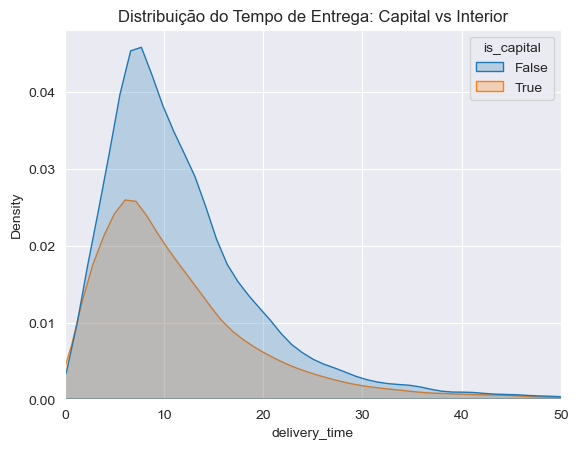

is_capital
False    12.256840
True     11.823612
Name: delivery_time, dtype: float64


In [22]:
capitais = [
    'sao paulo', 'rio de janeiro', 'belo horizonte', 'vitoria', 'curitiba', 'florianopolis', 
    'porto alegre', 'salvador', 'recife', 'fortaleza', 'natal', 'joao pessoa', 'maceio', 
    'aracaju', 'teresina', 'sao luis', 'belem', 'manaus', 'porto velho', 'rio branco', 
    'macapa', 'boa vista', 'palmas', 'cuiaba', 'campo grande', 'goiania', 'brasilia'
]

# Marcar se é capital ou não
customers['is_capital'] = customers['customer_city'].str.lower().isin(capitais)

# Calculando tempo de entrega
orders['delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

df_entrega = orders.merge(customers[['customer_id', 'is_capital']], on='customer_id')

# Remover nulos (pedidos não entregues ainda)
df_entrega = df_entrega.dropna(subset=['delivery_time'])

sns.kdeplot(data=df_entrega, x='delivery_time', hue='is_capital', fill=True)
plt.xlim(0, 50)
plt.title("Distribuição do Tempo de Entrega: Capital vs Interior")
plt.show()

print(df_entrega.groupby('is_capital')['delivery_time'].mean())

In [ ]:
df_orders_joined = pd. 